In [7]:
import sys
sys.path.append("..")

In [8]:
import shap
import joblib
import pandas as pd
from src.pipeline import preprocess_data

# Load data and model
df = pd.read_csv("../data/raw/creditcard.csv")
df = df.drop_duplicates()
X_train, X_test, y_train, y_test = preprocess_data(df)
model = joblib.load("../models/xgboost_fraud_model.pkl")

In [9]:
# Verify everything loaded correctly
print("X_test shape:", X_test.shape)
print("Model type:", type(model))

X_test shape: (56746, 30)
Model type: <class 'xgboost.sklearn.XGBClassifier'>


In [10]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (56746, 30)


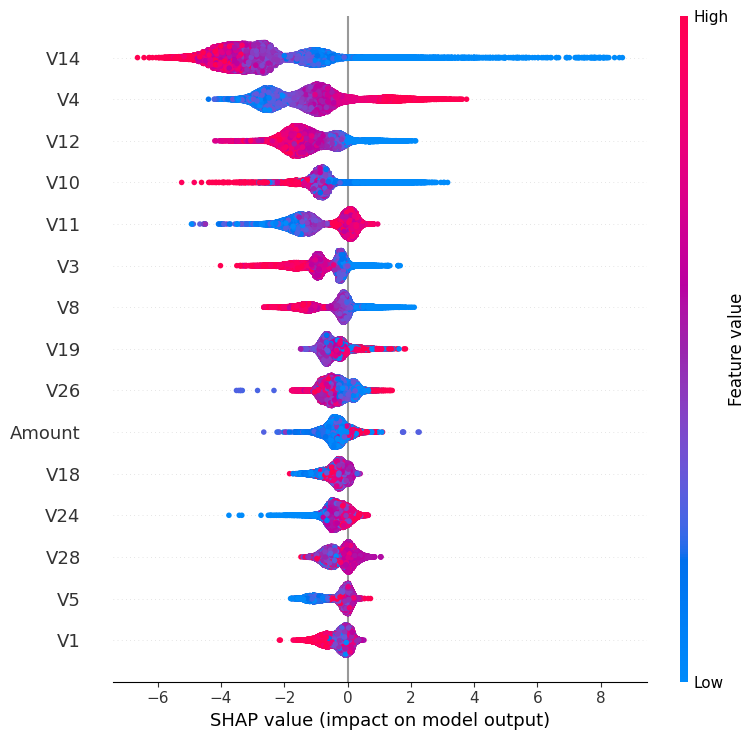

Plot saved.


In [12]:
# Plot top 15 most important features
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

# SHAP Feature Importance Analysis

## Key Findings
- **V14 is the most important feature** — widest SHAP spread, reaches -6, strongly drives fraud predictions
- **V4, V12, V10** are next most important features
- **Amount has almost no influence** — dots clustered near zero, model doesn't rely on transaction size
- High V14 values push toward fraud, low V14 values push toward legitimate

## Limitation
V1-V28 are PCA-transformed features — real-world meaning is unknown.
SHAP explains the model technically but results cannot be explained to regulators
or customers in plain business language without original features.